# 🤖 RE608 — Legged Robot
## Week 7: Gait Planning — Quadruped & Hexapod

---

| | |
|---|---|
| **Nama** | Sistra Amanda Sinaga |
| **NIM** | 4222301011 |
| **Kelas** | Robotika A |
| **Mata Kuliah** | RE608 – Legged Robot |
| **Program Studi** | Teknologi Rekayasa Robotika |
| **Institusi** | Politeknik Negeri Batam |
| **Minggu** | 7 – Gait Planning |

---

### Deskripsi Praktikum

Notebook ini mendemonstrasikan bagaimana merencanakan jadwal fase gerak (*gait scheduler*)
dan memvisualisasikan diagram *gait* untuk robot berkaki.  
Kita akan:
1. Memahami parameter dasar gait (Stride Period, Duty Factor, Phase Offset).
2. Menganalisis **Trot Gait** dan **Crawl Gait** pada *quadruped* (4 kaki).
3. Merancang dan memverifikasi **Tripod Gait** untuk *hexapod* (6 kaki).
4. Menganalisis perbedaan stabilitas antara kedua jenis gait tersebut.


---
## 0. Import Library & Konfigurasi Environment


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib

# Konfigurasi Google Colab untuk menampilkan animasi matplotlib
matplotlib.rcParams['animation.html'] = 'jshtml'

print("✅ Environment siap!")
print(f"   NumPy  : {np.__version__}")
print(f"   Matplotlib : {matplotlib.__version__}")


✅ Environment siap!
   NumPy  : 2.0.2
   Matplotlib : 3.10.0


---
## 1. Definisi Parameter Gait

Sebuah siklus *gait* ditentukan oleh tiga parameter utama:

| Parameter | Simbol | Deskripsi |
|---|---|---|
| **Stride Period** | $T$ | Waktu satu siklus penuh (detik) |
| **Duty Factor** | $\beta$ | Rasio waktu kaki di tanah (*stance*) terhadap $T$ |
| **Phase Offset** | $\phi$ | Perbedaan waktu mulai siklus antar kaki (0–1) |

**Aturan:**
- Fase $< \beta$ → **Stance** (kaki di tanah, menopang berat)
- Fase $\geq \beta$ → **Swing** (kaki di udara, melangkah maju)


---
## 2. Quadruped Gait Scheduler (4 Kaki)

Kelas berikut mengimplementasikan *gait scheduler* untuk robot berkaki empat
dengan support **Trot Gait** dan **Crawl Gait**.


  TROT GAIT  |  β = 0.5
  Pasangan diagonal: FL+RR dan FR+RL


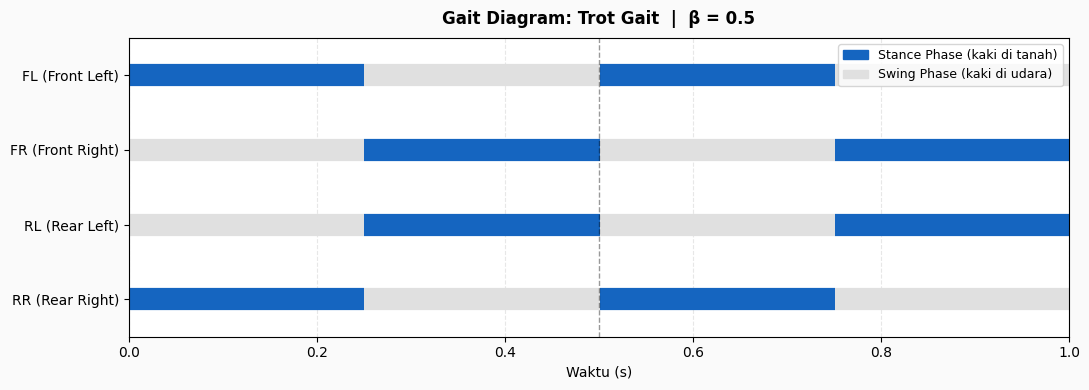


  CRAWL GAIT  |  β = 0.75
  Satu kaki swing, tiga kaki stance


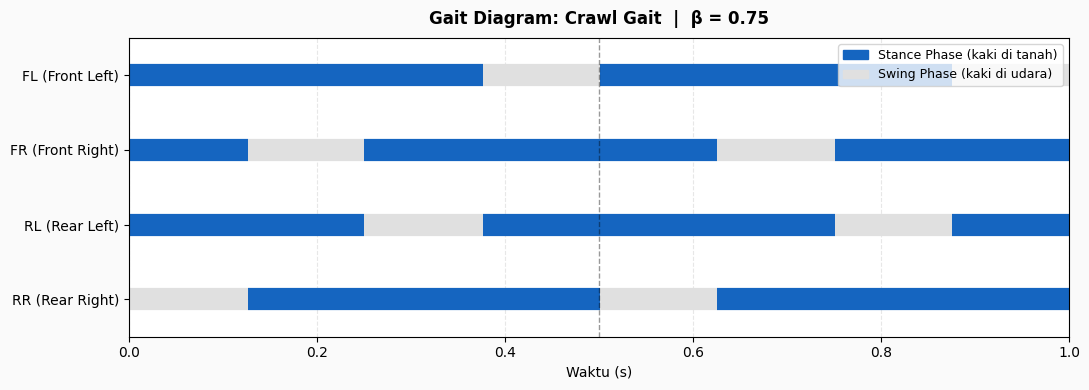

In [2]:
class QuadrupedGaitScheduler:
    """
    Gait Scheduler untuk robot quadruped (4 kaki).

    Kaki:
        FL = Front Left  (depan kiri)
        FR = Front Right (depan kanan)
        RL = Rear Left   (belakang kiri)
        RR = Rear Right  (belakang kanan)
    """

    def __init__(self, T=1.0):
        self.T    = T
        self.legs = ['FL (Front Left)', 'FR (Front Right)',
                     'RL (Rear Left)',  'RR (Rear Right)']

    def get_phase(self, t, offset):
        """Hitung fase ternormalisasi [0, 1)."""
        return ((t / self.T) + offset) % 1.0

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500)

        fig, ax = plt.subplots(figsize=(11, 4))
        fig.patch.set_facecolor('#FAFAFA')

        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            stance = np.where(phases < duty_factor, 1, 0)
            y      = 3 - i

            for t_idx in range(len(time_steps) - 1):
                col = '#1565C0' if stance[t_idx] == 1 else '#E0E0E0'
                ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [y, y],
                        color=col, lw=16, solid_capstyle='butt')

        # Garis pemisah siklus
        ax.axvline(self.T, color='black', lw=1, ls='--', alpha=0.4, label='Siklus ke-2')

        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(self.legs[::-1], fontsize=10)
        ax.set_xlabel('Waktu (s)', fontsize=10)
        ax.set_title(f'Gait Diagram: {title}  |  β = {duty_factor}',
                     fontsize=12, fontweight='bold', pad=10)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.set_xlim(0, 2 * self.T)
        ax.set_ylim(-0.5, 3.5)

        pS = mpatches.Patch(color='#1565C0', label='Stance Phase (kaki di tanah)')
        pW = mpatches.Patch(color='#E0E0E0', label='Swing Phase (kaki di udara)')
        ax.legend(handles=[pS, pW], loc='upper right', fontsize=9,
                  framealpha=0.8)
        plt.tight_layout()
        plt.show()


# ── Inisialisasi
scheduler = QuadrupedGaitScheduler(T=0.5)

# ── Trot Gait: pasangan diagonal bergerak bersamaan
print("=" * 50)
print("  TROT GAIT  |  β = 0.5")
print("  Pasangan diagonal: FL+RR dan FR+RL")
print("=" * 50)
trot_offsets = [0.0, 0.5, 0.5, 0.0]   # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.5, offsets=trot_offsets, title='Trot Gait')

# ── Crawl Gait: gerak satu per satu, stabil statis
print()
print("=" * 50)
print("  CRAWL GAIT  |  β = 0.75")
print("  Satu kaki swing, tiga kaki stance")
print("=" * 50)
crawl_offsets = [0.0, 0.5, 0.25, 0.75]  # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.75, offsets=crawl_offsets, title='Crawl Gait')


---
## 3. Foot Trajectory (Lintasan Kaki)

Fungsi berikut menghitung posisi kaki $(x, z)$ berdasarkan fase gait saat ini.
- **Stance phase:** kaki bergerak mundur di tanah (mendorong tubuh maju).
- **Swing phase:** kaki terangkat membentuk busur sinusoidal.


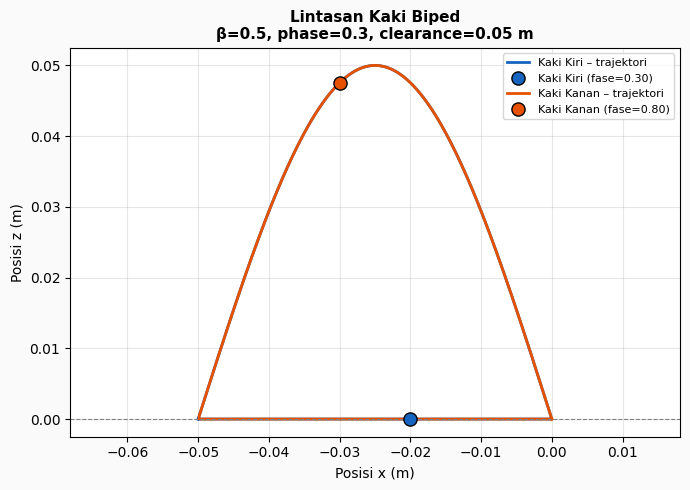

In [3]:
def foot_position_cmd(phase, beta,
                      x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0,  z_clearance=0.05):
    """
    Hitung posisi (x, z) kaki berdasarkan fase saat ini.

    Parameters
    ----------
    phase       : float, fase saat ini [0, 1)
    beta        : float, duty factor
    x_stance    : float, posisi x saat stance (m)
    x_lift      : float, posisi x saat lift-off / touch-down (m)
    z_ground    : float, tinggi tanah (m)
    z_clearance : float, tinggi maksimum kaki saat swing (m)

    Returns
    -------
    (x, z) : tuple[float, float]
    """
    if phase < beta:        # ── Stance
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:                   # ── Swing
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z


# ── Parameter (bisa diubah)
beta        = 0.5
phase_now   = 0.3
x_stance    = -0.05
x_lift      = 0.0
z_ground    = 0.0
z_clearance = 0.05

T       = 1.0
t_arr   = np.linspace(0, T, 400)
phases  = t_arr / T
offsets = {'Kaki Kiri': 0.0, 'Kaki Kanan': 0.5}
colors  = {'Kaki Kiri': '#1565C0', 'Kaki Kanan': '#E65100'}

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#FAFAFA')

for leg, offset in offsets.items():
    xs, zs = zip(*[foot_position_cmd((ph + offset) % 1.0,
                                     beta, x_stance, x_lift,
                                     z_ground, z_clearance)
                   for ph in phases])
    ax.plot(xs, zs, label=f'{leg} – trajektori', color=colors[leg], lw=2)

    # Posisi saat ini
    ph_cur  = (phase_now + offset) % 1.0
    x_c, z_c = foot_position_cmd(ph_cur, beta, x_stance, x_lift,
                                  z_ground, z_clearance)
    ax.scatter([x_c], [z_c], color=colors[leg], s=90,
               edgecolors='black', zorder=5,
               label=f'{leg} (fase={ph_cur:.2f})')

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Posisi x (m)', fontsize=10)
ax.set_ylabel('Posisi z (m)', fontsize=10)
ax.set_title(f'Lintasan Kaki Biped\n'
             f'β={beta}, phase={phase_now}, clearance={z_clearance} m',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper right')
ax.axis('equal')
plt.tight_layout()
plt.show()


---
## 4. Assignment: Hexapod Tripod Gait Design 🦾

> Hexapod dapat menggunakan **Tripod Gait** di mana 3 kaki membentuk fondasi segitiga
> yang stabil, secara bergantian (*alternating triangles*).

### Konsep Tripod Gait

```
     [L1]───────[R2]
       \        /
        \      /
        [L3/R3]
```

Dua segitiga bergantian:

| Kelompok | Kaki | Phase Offset | Aksi di t=0 |
|---|---|---|---|
| **Grup A** | L1, R2, L3 | 0.0 | Stance (di tanah) |
| **Grup B** | R1, L2, R3 | 0.5 | Swing (di udara) |

**Syarat stabilitas statis:** CoM (*center of mass*) harus selalu jatuh di dalam segitiga penopang → butuh minimal **3 kaki** di tanah setiap saat.


### Tugas 1 & 2 — Implementasi `HexapodGaitScheduler` + Matriks Offsets


In [4]:
# ══════════════════════════════════════════════════════════════════
# TUGAS 1 — Modifikasi kelas untuk menangani 6 kaki
# TUGAS 2 — Matriks offsets & duty factor Tripod Gait
# ══════════════════════════════════════════════════════════════════

class HexapodGaitScheduler:
    """
    Gait Scheduler untuk robot hexapod (6 kaki).

    Tripod Gait membagi 6 kaki menjadi dua kelompok segitiga yang
    saling bergantian sehingga robot selalu bertumpu pada 3 kaki:

        Grup A : L1 (depan kiri), R2 (tengah kanan), L3 (belakang kiri)
                 → phase offset 0.0  (stance di awal siklus)
        Grup B : R1 (depan kanan), L2 (tengah kiri), R3 (belakang kanan)
                 → phase offset 0.5  (swing di awal siklus)

    Duty Factor β = 0.5  →  50% stance | 50% swing per siklus
                         →  selalu tepat 3 kaki di tanah setiap saat
    """

    def __init__(self, T: float = 1.0):
        self.T    = T
        self.legs = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']

        # Pemetaan kaki ke kelompok
        self.group = {
            'L1': 'A', 'R2': 'A', 'L3': 'A',
            'R1': 'B', 'L2': 'B', 'R3': 'B',
        }
        self.group_color = {'A': '#1565C0', 'B': '#E65100'}

    # ── helpers ──────────────────────────────────────────────────
    def get_phase(self, t: np.ndarray, offset: float) -> np.ndarray:
        """Normalisasi fase ke [0, 1) dengan phase offset."""
        return ((t / self.T) + offset) % 1.0

    def is_stance(self, phase: np.ndarray, duty_factor: float) -> np.ndarray:
        """Kembalikan 1 (stance) atau 0 (swing) untuk tiap time-step."""
        return np.where(phase < duty_factor, 1, 0)

    # ── diagram gait ─────────────────────────────────────────────
    def plot_gait_diagram(self,
                          duty_factor : float,
                          offsets     : list,
                          title       : str = 'Tripod Gait',
                          n_cycles    : int = 2):
        """
        Plot diagram Gantt gait untuk seluruh 6 kaki.
        Setiap kelompok ditampilkan dengan warna berbeda.
        """
        time_steps = np.linspace(0, n_cycles * self.T, 1000)
        n_legs     = len(self.legs)

        fig, ax = plt.subplots(figsize=(13, 5))
        fig.patch.set_facecolor('#FAFAFA')

        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            stance = self.is_stance(phases, duty_factor)
            y      = (n_legs - 1) - i
            c_st   = self.group_color[self.group[leg]]

            for t_idx in range(len(time_steps) - 1):
                col = c_st if stance[t_idx] == 1 else '#E0E0E0'
                ax.plot(
                    [time_steps[t_idx], time_steps[t_idx + 1]],
                    [y, y],
                    color=col, lw=18, solid_capstyle='butt'
                )

        # Garis pemisah siklus
        for c in range(1, n_cycles + 1):
            ax.axvline(c * self.T, color='black', lw=0.9,
                       ls='--', alpha=0.45)

        # Label "Grup A / Grup B" di kiri
        for i, leg in enumerate(self.legs):
            y = (n_legs - 1) - i
            grp = self.group[leg]
            ax.text(-0.07 * n_cycles * self.T, y,
                    f'Grup {grp}', va='center', ha='right',
                    fontsize=8, color=self.group_color[grp],
                    fontweight='bold')

        ax.set_yticks(range(n_legs))
        ax.set_yticklabels(self.legs[::-1], fontsize=11)
        ax.set_xlabel('Waktu (s)', fontsize=11)
        ax.set_title(
            f'Gait Diagram: {title}  |  β = {duty_factor}  |  T = {self.T} s',
            fontsize=13, fontweight='bold', pad=12
        )
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.set_xlim(0, n_cycles * self.T)
        ax.set_ylim(-0.6, n_legs - 0.4)

        pA = mpatches.Patch(color='#1565C0', label='Grup A Stance (L1, R2, L3)')
        pB = mpatches.Patch(color='#E65100', label='Grup B Stance (R1, L2, R3)')
        pS = mpatches.Patch(color='#E0E0E0', label='Swing Phase')
        ax.legend(handles=[pA, pB, pS], loc='upper right',
                  fontsize=9, framealpha=0.85)

        plt.tight_layout()
        plt.show()

    # ── verifikasi stabilitas ────────────────────────────────────
    def verify_stability(self,
                         duty_factor : float,
                         offsets     : list,
                         n_samples   : int = 300):
        """
        Verifikasi apakah jumlah kaki stance selalu >= 3.

        Syarat stabilitas statis hexapod:
            Minimal 3 kaki di tanah setiap saat
            → membentuk segitiga penopang (*support polygon*)
            → CoM harus jatuh di dalam segitiga tersebut.
        """
        time_steps = np.linspace(0, self.T, n_samples, endpoint=False)

        counts = []
        for t in time_steps:
            n_st = sum(
                1 for off in offsets
                if ((t / self.T) + off) % 1.0 < duty_factor
            )
            counts.append(n_st)

        counts        = np.array(counts)
        always_stable = bool(np.all(counts >= 3))

        fig, ax = plt.subplots(figsize=(11, 3.5))
        fig.patch.set_facecolor('#FAFAFA')

        ax.fill_between(time_steps, counts,
                        alpha=0.25, color='#1565C0')
        ax.plot(time_steps, counts,
                color='#1565C0', lw=2.5,
                label='Jumlah kaki di tanah (stance)')
        ax.axhline(3, color='#D32F2F', ls='--', lw=2,
                   label='Minimum stabil = 3 kaki')
        ax.axhline(6, color='gray', ls=':', lw=1, alpha=0.5)

        ax.set_xlabel('Waktu (s)', fontsize=10)
        ax.set_ylabel('Jumlah Kaki Stance', fontsize=10)
        ax.set_title('Verifikasi Stabilitas — Tripod Hexapod',
                     fontsize=12, fontweight='bold')
        ax.set_ylim(0, 7)
        ax.set_yticks(range(7))
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(alpha=0.3)

        status_txt = ("STABIL: selalu tepat 3 kaki di tanah"
                      if always_stable
                      else "TIDAK STABIL: ada saat < 3 kaki!")
        ax.text(self.T * 0.5, 5.2, status_txt,
                ha='center', fontsize=11, fontweight='bold',
                color='#2E7D32' if always_stable else '#C62828',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='gray', alpha=0.8))

        plt.tight_layout()
        plt.show()

        print("\n" + "="*52)
        print("  Hasil Verifikasi Stabilitas — Tripod Hexapod")
        print("="*52)
        print(f"  Min kaki stance setiap saat : {counts.min()}")
        print(f"  Max kaki stance setiap saat : {counts.max()}")
        print(f"  Selalu >= 3 kaki            : {always_stable}")
        print(f"  Kesimpulan  : {'STABIL STATIS' if always_stable else 'TIDAK STABIL'}")
        print("="*52)

        return always_stable, counts


print("✅ HexapodGaitScheduler berhasil didefinisikan.")
print()
print("Kaki        :", ['L1','L2','L3','R1','R2','R3'])
print("Grup A      : L1, R2, L3  (offset 0.0)")
print("Grup B      : R1, L2, R3  (offset 0.5)")


✅ HexapodGaitScheduler berhasil didefinisikan.

Kaki        : ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']
Grup A      : L1, R2, L3  (offset 0.0)
Grup B      : R1, L2, R3  (offset 0.5)


### Tugas 3 — Plot Diagram Gait & Verifikasi Stabilitas


  Parameter Tripod Gait
  L1  →  Grup A  |  offset = 0.0
  L2  →  Grup B  |  offset = 0.5
  L3  →  Grup A  |  offset = 0.0
  R1  →  Grup B  |  offset = 0.5
  R2  →  Grup A  |  offset = 0.0
  R3  →  Grup B  |  offset = 0.5

  Duty Factor β = 0.5
  Kaki stance setiap saat = 3

📊 Diagram Gait:


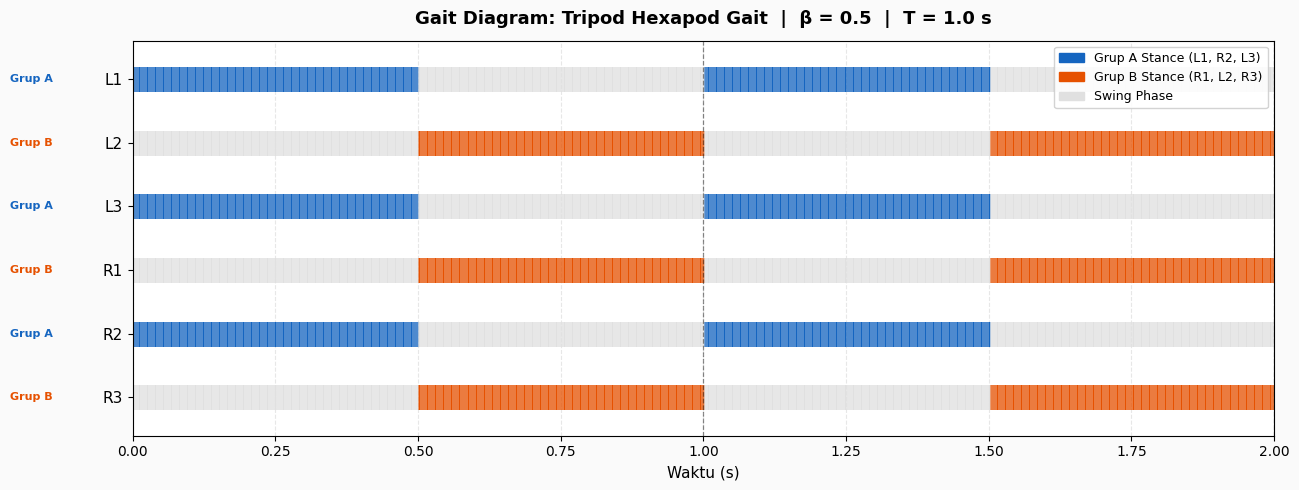


🔍 Verifikasi Stabilitas:


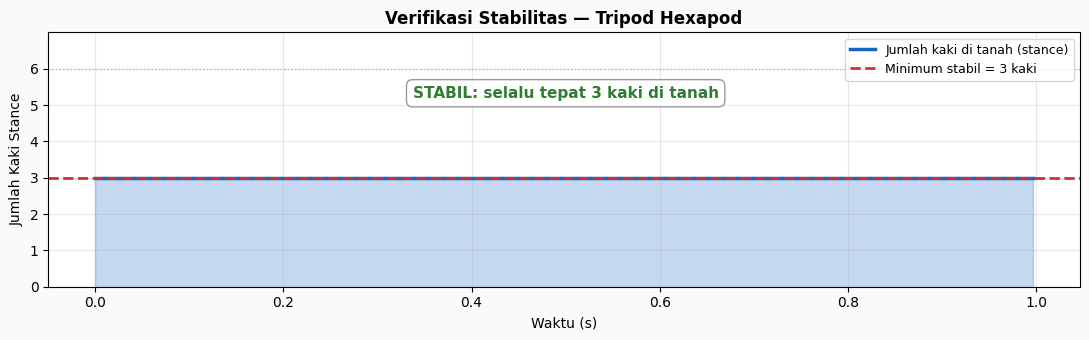


  Hasil Verifikasi Stabilitas — Tripod Hexapod
  Min kaki stance setiap saat : 3
  Max kaki stance setiap saat : 3
  Selalu >= 3 kaki            : True
  Kesimpulan  : STABIL STATIS


(True,
 array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3,

In [5]:
# ══════════════════════════════════════════════════════════════════
# TUGAS 3 — Jalankan HexapodGaitScheduler untuk Tripod Gait
# ══════════════════════════════════════════════════════════════════

# ── Matriks offsets Tripod Gait ──────────────────────────────────
#
#   Urutan mengikuti self.legs = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']
#
#   Leg  | Grup | Offset
#   -----+------+-------
#   L1   |  A   |  0.0   ← stance di awal siklus
#   L2   |  B   |  0.5   ← swing  di awal siklus
#   L3   |  A   |  0.0
#   R1   |  B   |  0.5
#   R2   |  A   |  0.0
#   R3   |  B   |  0.5
#
tripod_offsets = [0.0,  # L1  → Grup A
                  0.5,  # L2  → Grup B
                  0.0,  # L3  → Grup A
                  0.5,  # R1  → Grup B
                  0.0,  # R2  → Grup A
                  0.5]  # R3  → Grup B

tripod_duty = 0.5   # β = 0.5 adalah nilai baku Tripod Gait

print("=" * 52)
print("  Parameter Tripod Gait")
print("=" * 52)
for leg, off in zip(['L1','L2','L3','R1','R2','R3'], tripod_offsets):
    grp = 'A' if off == 0.0 else 'B'
    print(f"  {leg}  →  Grup {grp}  |  offset = {off}")
print(f"\n  Duty Factor β = {tripod_duty}")
print(f"  Kaki stance setiap saat = {int(6 * tripod_duty)}")
print("=" * 52)

# ── Buat scheduler & plot ────────────────────────────────────────
hex_scheduler = HexapodGaitScheduler(T=1.0)

print("\n📊 Diagram Gait:")
hex_scheduler.plot_gait_diagram(
    duty_factor = tripod_duty,
    offsets     = tripod_offsets,
    title       = 'Tripod Hexapod Gait'
)

print("\n🔍 Verifikasi Stabilitas:")
hex_scheduler.verify_stability(
    duty_factor = tripod_duty,
    offsets     = tripod_offsets
)


---
### Tugas 4 — Analisis: Perbedaan Stabilitas Trot Quadruped vs Tripod Hexapod

---

#### A. Trot Gait — Quadruped (4 Kaki)

Pada **Trot Gait**, robot berkaki empat menggerakkan dua kaki **diagonal** secara bersamaan:

- **Grup diagonal 1:** FL + RR → phase offset `0.0`
- **Grup diagonal 2:** FR + RL → phase offset `0.5`

Dengan duty factor β = 0.5, di setiap setengah siklus hanya **2 kaki** yang berada di tanah.

**Analisis stabilitas Trot:**
- Dua titik tumpu hanya membentuk **garis** (*line of support*), bukan bidang.
- Pusat massa (CoM) harus tepat jatuh di atas garis tersebut → sangat rentan jatuh ke samping.
- Trot adalah **dynamically stable gait**: stabilitas bergantung pada momentum gerak maju.
- Jika robot berhenti mendadak di tengah fase swing → **risiko jatuh lateral** sangat tinggi.
- Kecepatan operasi: **sedang hingga tinggi**.

---

#### B. Tripod Gait — Hexapod (6 Kaki)

Pada **Tripod Gait**, keenam kaki dibagi menjadi dua kelompok segitiga:

- **Grup A:** L1, R2, L3 → offset `0.0`
- **Grup B:** R1, L2, R3 → offset `0.5`

Dengan β = 0.5, pada **setiap saat** tepat **3 kaki** berada di tanah membentuk **segitiga penopang** (*support polygon*).

**Analisis stabilitas Tripod:**
- Tiga titik tumpu membentuk **bidang segitiga** → CoM dapat dijaga selalu di dalam segitiga.
- **Statically stable gait**: stabil bahkan saat robot berhenti di posisi manapun dalam siklus.
- *Stability margin* = jarak minimum CoM ke sisi segitiga penopang → selalu positif sepanjang siklus.
- Sangat cocok untuk terrain tidak rata, kemiringan, dan aplikasi presisi.

---

#### C. Tabel Perbandingan

| Aspek | Trot Quadruped | Tripod Hexapod |
|---|:---:|:---:|
| Jumlah kaki |  4 |  6 |
| Kaki stance minimum | **2** | **3** |
| Bentuk tumpuan | Garis (1D) | Segitiga (2D) |
| Jenis stabilitas | **Dinamis** | **Statis** |
| Bisa berhenti kapanpun | ❌ Berisiko | ✅ Aman |
| Duty Factor β | 0.5 | 0.5 |
| Kecepatan relatif | Lebih tinggi | Lebih rendah |
| Toleransi terrain kasar | Rendah | **Tinggi** |
| Kompleksitas mekanik | Sedang | Tinggi |

---

#### D. Kesimpulan

> **Tripod Hexapod secara fundamental lebih stabil** dibandingkan Trot Quadruped karena:
>
> 1. Selalu memiliki **3 titik tumpu** yang membentuk *support polygon* (bidang segitiga), bukan sekadar garis.
> 2. Memberikan **stabilitas statis** yang tidak bergantung pada kecepatan gerak.
> 3. Robot dapat **berhenti kapan saja** di tengah siklus gait tanpa risiko jatuh.
>
> Tradeoff-nya: hexapod membutuhkan **6 aktuator** dan **kompleksitas kontrol** yang lebih tinggi.  
> Namun untuk aplikasi seperti robot eksplorasi, inspeksi industri, atau navigasi terrain tak beraturan,
> **Tripod Hexapod adalah pilihan yang jauh lebih andal**.

---



---
## 5. Catatan Implementasi Lanjutan

Saat mengintegrasikan luaran *gait scheduler* ini ke simulasi *forward/inverse kinematics*:

1. **Paksa sendi coxa** beroperasi konstan pada bidang XY untuk menghindari perhitungan matriks singular.
2. **Hapus titik koordinat base** dari matriks simulasi kaki untuk mempercepat konvergensi algoritma IK.
3. **Transisi stance → swing** harus dilakukan saat kaki tepat di titik `x_lift` untuk menghindari discontinuity.

---

